## Preprocessing and supplementary package

Upload the original board-log CSV when prompted. The uploaded table is preserved as `00_board_logs.csv` and is the source input for all subsequent processing.

The notebook then creates the preprocessed coding units and the derived tables used for the sequence, transition, group-focus, and text-based analyses. The final requirements from Team A and Team B are included as separate text files using the wording recorded on the study boards.

The final export creates `S3_Study_Data_and_Analysis_Outputs.zip` with the source input, processed and derived data, the two requirement files, and a README. Intermediate plotting helpers and duplicate figure exports are not included.


### Running the notebook

Run the notebook from top to bottom.

1. Upload the original board-log CSV when prompted.
2. The notebook stores that input as `00_board_logs.csv`.
3. Processing and analysis tables are generated from this input.
4. The final cell writes the Team A and Team B requirement text files, creates `README.md`, and packages the substantive files into `data_and_analysis_outputs.zip`.

For submission, keep this notebook with Supplementary File S3 as the computational record used to generate the package.


In [1]:
# ============================================================
# PREPROCESS ORIGINAL BOARD LOGS INTO CODING UNITS
# Outputs:
# 00_board_logs.csv
# 01_reference_table.csv
# 02_preprocessed_coding_units.csv
#
# 00_board_logs.csv is the preserved source input.
# The remaining files are generated from this input.
# ============================================================

!pip -q install pandas openpyxl

from google.colab import files
from pathlib import Path
import pandas as pd
import numpy as np
import re

OUT_DIR = Path("/content/pilot_analysis_outputs")
DATA_DIR = OUT_DIR / "data"
INTERMEDIATE_DIR = OUT_DIR / "intermediate"
FIGURE_DIR = OUT_DIR / "figures"

for folder in [OUT_DIR, DATA_DIR, INTERMEDIATE_DIR, FIGURE_DIR]:
    folder.mkdir(exist_ok=True)

PARAMS = {
    "split_pattern": r";|\n|•|\u2022",
    "split_numbered_items": True
}

COLUMN_NAMES = {
    "timestamp": "Timestamp",
    "time_point": "Time point",
    "actor": "Actor",
    "decision_point": "Decision point",
    "question": "Code of card",
    "text": "Added contribution on board"
}

reference = {
    "Q1": ["SEARCH", "What is missing?", "Uncaptured inputs", "Uncaptured",
           "Find a missing step. Spot a missing detail. Uncover a hidden cue.",
           "Information is missing, absent, unknown, incomplete, unavailable, or not yet captured."],
    "Q2": ["SEARCH", "Where else can I look?", "Piling inputs", "Piling",
           "Check another source. Ask for a second opinion. Look for similar examples.",
           "Information comes from several sources, accumulates, overlaps, or requires looking elsewhere."],
    "Q3": ["SHAPE", "Can I break this into parts?", "Merged inputs", "Merged",
           "Sorting things apart. List each thing by itself. Split by common feature.",
           "Different issues, data types, findings, or actions are combined and need to be separated."],
    "Q4": ["SHAPE", "Can this fit into the bigger picture?", "Isolated inputs", "Isolated",
           "Add to the matching group. Look for fitting patterns. Combine by common feature.",
           "Information is separated from the wider clinical picture and needs to be connected."],
    "Q5": ["SHAPE", "What can I throw away?", "Irrelevant inputs", "Irrelevant",
           "Skip irrelevant details. Remove redundant info. Drop unhelpful steps.",
           "Information is normal, redundant, unnecessary, low value, or can be removed."],
    "Q6": ["CHECK", "What matters most?", "Deferred urgent inputs", "Deferred urgent",
           "Show what is most urgent. Watch for big changes. Find what helps most. Spot the biggest problem.",
           "Information concerns urgency, severity, priority, escalation, or time critical action."],
    "Q7": ["CHECK", "How do I know this is right?", "Unchecked inputs", "Unchecked",
           "Check with two distinct methods. Compare with recent details. Test in real life.",
           "Information needs verification, comparison, confirmation, source checking, traceability, or audit."],
    "Q8": ["ACT", "What should I do first?", "Delayed inputs", "Delayed",
           "Take the most critical step. Unblock what holds things up. Act on what you can now.",
           "Information is delayed, action is blocked, or the team must act with what is available now."]
}

QUESTION_ORDER = list(reference.keys())

ACTOR_LABELS = {
    "Clinical input": "Clinical team",
    "Team A": "SE team A",
    "Team B": "SE team B"
}

def actor_label(actor):
    return ACTOR_LABELS.get(actor, actor)

reference_table = pd.DataFrame([
    {
        "question_code": q,
        "question_group": reference[q][0],
        "guiding_question": reference[q][1],
        "breakdown": reference[q][2],
        "short_breakdown": reference[q][3],
        "practical_steps": reference[q][4],
        "coding_rule": reference[q][5]
    }
    for q in QUESTION_ORDER
])

def split_entry(text):
    if pd.isna(text):
        return []

    text = str(text).strip()
    text = re.sub(r"\r\n|\r", "\n", text)

    if PARAMS["split_numbered_items"]:
        text = re.sub(r"(?<!\d)\s+(\d{1,2}\.\s+)", r"\n\1", text)

    parts = re.split(PARAMS["split_pattern"], text)

    out = []
    for part in parts:
        part = re.sub(r"\s+", " ", part).strip().strip(" .")
        if part:
            out.append(part[:1].lower() + part[1:])

    return out

uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

raw_df = pd.read_csv(csv_file)
raw_df.columns = raw_df.columns.str.strip()

missing = [c for c in COLUMN_NAMES.values() if c not in raw_df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

entries = raw_df[raw_df[COLUMN_NAMES["question"]].isin(QUESTION_ORDER)].copy()

entries = entries.reset_index().rename(columns={
    "index": "original_row_order",
    COLUMN_NAMES["timestamp"]: "timestamp",
    COLUMN_NAMES["time_point"]: "time_point",
    COLUMN_NAMES["actor"]: "actor",
    COLUMN_NAMES["decision_point"]: "decision_point",
    COLUMN_NAMES["question"]: "question_code",
    COLUMN_NAMES["text"]: "original_entry"
})

rows = []

for _, row in entries.iterrows():
    q = row["question_code"]
    ref = reference_table.set_index("question_code").loc[q]

    for unit_number, unit_text in enumerate(split_entry(row["original_entry"]), start=1):
        rows.append({
            "coding_unit_id": f"U{len(rows) + 1:03d}",
            "original_row_order": row["original_row_order"],
            "unit_number_in_entry": unit_number,
            "timestamp": row["timestamp"],
            "time_point": row["time_point"],
            "actor": row["actor"],
            "actor_label": actor_label(row["actor"]),
            "decision_point": row["decision_point"],
            "question_code": q,
            "question_group": ref["question_group"],
            "guiding_question": ref["guiding_question"],
            "breakdown": ref["breakdown"],
            "short_breakdown": ref["short_breakdown"],
            "practical_steps": ref["practical_steps"],
            "coding_rule": ref["coding_rule"],
            "coding_unit_text": unit_text,
            "original_entry": row["original_entry"]
        })

coding_units = pd.DataFrame(rows).sort_values(
    ["original_row_order", "unit_number_in_entry"]
).reset_index(drop=True)

coding_units["global_order"] = np.arange(1, len(coding_units) + 1)
coding_units["order_within_actor"] = coding_units.groupby("actor").cumcount() + 1

# Preserve the uploaded board-log table as the source data used by the notebook.
raw_df.to_csv(DATA_DIR / "00_board_logs.csv", index=False)
reference_table.to_csv(DATA_DIR / "01_reference_table.csv", index=False)
coding_units.to_csv(DATA_DIR / "02_preprocessed_coding_units.csv", index=False)

print("Saved:")
print(DATA_DIR / "00_board_logs.csv")
print(DATA_DIR / "01_reference_table.csv")
print(DATA_DIR / "02_preprocessed_coding_units.csv")
print("Original rows:", len(raw_df))
print("Q1-Q8 board entries:", len(entries))
print("Coding units:", len(coding_units))
display(coding_units.head())

Saving 00_board_logs.csv to 00_board_logs.csv
Saved:
/content/pilot_analysis_outputs/data/00_board_logs.csv
/content/pilot_analysis_outputs/data/01_reference_table.csv
/content/pilot_analysis_outputs/data/02_preprocessed_coding_units.csv
Original rows: 100
Q1-Q8 board entries: 85
Coding units: 112


,coding_unit_id,original_row_order,unit_number_in_entry,timestamp,time_point,actor,actor_label,decision_point,question_code,question_group,guiding_question,breakdown,short_breakdown,practical_steps,coding_rule,coding_unit_text,original_entry,global_order,order_within_actor
0,U001,4,1,11:45,00:15:00,Clinical input,Clinical team,1.0,Q1,SEARCH,What is missing?,Uncaptured inputs,Uncaptured,Find a missing step. Spot a missing detail. Un...,"Information is missing, absent, unknown, incom...",laboratory and instrumental data,Laboratory and instrumental data; history of p...,1,1
1,U002,4,2,11:45,00:15:00,Clinical input,Clinical team,1.0,Q1,SEARCH,What is missing?,Uncaptured inputs,Uncaptured,Find a missing step. Spot a missing detail. Un...,"Information is missing, absent, unknown, incom...","history of present illness, past medical histo...",Laboratory and instrumental data; history of p...,2,2
2,U003,4,3,11:45,00:15:00,Clinical input,Clinical team,1.0,Q1,SEARCH,What is missing?,Uncaptured inputs,Uncaptured,Find a missing step. Spot a missing detail. Un...,"Information is missing, absent, unknown, incom...",no history available from earlier stages of care,Laboratory and instrumental data; history of p...,3,3
3,U004,5,1,11:45,00:15:00,Clinical input,Clinical team,1.0,Q2,SEARCH,Where else can I look?,Piling inputs,Piling,Check another source. Ask for a second opinion...,"Information comes from several sources, accumu...",patient history,Patient history; communication with relatives ...,4,4
4,U005,5,2,11:45,00:15:00,Clinical input,Clinical team,1.0,Q2,SEARCH,Where else can I look?,Piling inputs,Piling,Check another source. Ask for a second opinion...,"Information comes from several sources, accumu...",communication with relatives or accompanying p...,Patient history; communication with relatives ...,5,5


## Step 1. Analysis

This step starts from `02_preprocessed_coding_units.csv` and produces the substantive tables reported in the manuscript.

- Consecutive repetitions of the same question code are collapsed for transition analysis.
- Observed transitions are compared with randomly reordered sequences.
- Local group focus is calculated with the moving window specified in the manuscript.
- Four text representations are constructed for the question-fit analysis.
- TF-IDF and sentence-embedding separation measures are calculated.
- The original and alternative Q8 wording are compared using the procedure described in the manuscript.

Only substantive tables needed to inspect the reported analyses are retained in the supplementary data folder. Plotting-only helpers are written separately and are not packaged.


In [2]:
# ============================================================
# STEP 1. PROCESSING
# Starts from:
# 01_reference_table.csv
# 02_preprocessed_coding_units.csv
# ============================================================

!pip -q install pandas openpyxl scipy scikit-learn sentence-transformers

from pathlib import Path
import shutil
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

OUT_DIR = Path("/content/pilot_analysis_outputs")
DATA_DIR = OUT_DIR / "data"
INTERMEDIATE_DIR = OUT_DIR / "intermediate"
FIGURE_DIR = OUT_DIR / "figures"

for folder in [OUT_DIR, DATA_DIR, INTERMEDIATE_DIR, FIGURE_DIR]:
    folder.mkdir(exist_ok=True)

PARAMS = {
    "unit_step": 2.25,
    "minimum_count_for_new_repeated_pattern": 2,
    "random_reordering_iterations": 1000,
    "random_seed": 42,
    "focus_window_size": 6,
    "high_focus_threshold": 0.60,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "tfidf_ngram_range": (1, 2),
    "tfidf_min_df": 1,
    "q8_original": "What should I do first?",
    "q8_revised": "What can I do next?"
}

ACTOR_ORDER = ["Clinical input", "Team A", "Team B"]
PLANNED_ACTORS = {"Team A", "Team B"}
PLANNED_PATTERNS = {"Q1→Q2": ("Q1", "Q2"), "Q3→Q4": ("Q3", "Q4"), "Q6→Q7": ("Q6", "Q7")}

reference_table = pd.read_csv(DATA_DIR / "01_reference_table.csv")
coding_units = pd.read_csv(DATA_DIR / "02_preprocessed_coding_units.csv")

QUESTION_ORDER = reference_table["question_code"].tolist()
BREAKDOWN_ORDER = reference_table["breakdown"].tolist()
REF = reference_table.set_index("question_code").to_dict("index")

def actor_label(actor):
    labels = {"Clinical input": "Clinical team", "Team A": "SE team A", "Team B": "SE team B"}
    return labels.get(actor, actor)

def get_actor_order(values):
    values = list(pd.Series(values).dropna().drop_duplicates())
    out = [a for a in ACTOR_ORDER if a in values]
    out += [a for a in values if a not in out]
    return out

def parse_timestamp_series(series):
    parsed = pd.to_datetime(series, errors="coerce")
    if parsed.notna().sum() == 0:
        parsed = pd.to_datetime("2000-01-01 " + series.astype(str), errors="coerce")
    return parsed

def build_sequence_plot_data(units_df):
    g = units_df.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)
    g["x_position"] = np.arange(len(g)) * PARAMS["unit_step"]
    g["phrase_index"] = np.arange(1, len(g) + 1)
    g["parsed_timestamp"] = parse_timestamp_series(g["timestamp"])

    if g["parsed_timestamp"].notna().sum() > 0:
        first_time = g["parsed_timestamp"].dropna().min()
        g["elapsed_minutes"] = (g["parsed_timestamp"] - first_time).dt.total_seconds() / 60
    else:
        g["elapsed_minutes"] = np.nan

    separators = []
    for i in range(1, len(g)):
        changed = (
            g.loc[i - 1, "decision_point"] != g.loc[i, "decision_point"]
            or g.loc[i - 1, "timestamp"] != g.loc[i, "timestamp"]
        )
        if changed:
            separators.append({
                "line_x": (g.loc[i - 1, "x_position"] + g.loc[i, "x_position"]) / 2,
                "phrase_index": g.loc[i, "phrase_index"],
                "left_time": g.loc[i - 1, "timestamp"],
                "right_time": g.loc[i, "timestamp"],
                "left_decision": g.loc[i - 1, "decision_point"],
                "right_decision": g.loc[i, "decision_point"],
                "elapsed_minutes": g.loc[i, "elapsed_minutes"]
            })

    return g, pd.DataFrame(separators)

def collapse_neighbouring_same_questions(sequence_df):
    def collapse_group(group):
        group = group.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)
        keep = []
        previous_q = None
        for i, row in group.iterrows():
            if row["question_code"] != previous_q:
                keep.append(i)
            previous_q = row["question_code"]
        return group.loc[keep].reset_index(drop=True)

    return sequence_df.groupby("actor", group_keys=False).apply(collapse_group).reset_index(drop=True)

def classify_pattern(actor, path_tuple, count):
    if actor in PLANNED_ACTORS and path_tuple in PLANNED_PATTERNS.values():
        return "planned"
    if count >= PARAMS["minimum_count_for_new_repeated_pattern"]:
        return "new repeated"
    return "one-time"

def build_pattern_tables(collapsed_df):
    events = []

    for actor, g in collapsed_df.groupby("actor"):
        g = g.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)

        for i in range(len(g) - 1):
            from_q = g.loc[i, "question_code"]
            to_q = g.loc[i + 1, "question_code"]

            events.append({
                "actor": actor,
                "actor_label": actor_label(actor),
                "from_q": from_q,
                "to_q": to_q,
                "question_path": f"{from_q}→{to_q}",
                "from_breakdown": REF[from_q]["breakdown"],
                "to_breakdown": REF[to_q]["breakdown"],
                "breakdown_sequence": f"{REF[from_q]['breakdown']} → {REF[to_q]['breakdown']}",
                "path_tuple": (from_q, to_q),
                "start_unit_id": g.loc[i, "coding_unit_id"],
                "end_unit_id": g.loc[i + 1, "coding_unit_id"],
                "start_x": g.loc[i, "x_position"],
                "end_x": g.loc[i + 1, "x_position"]
            })

    pattern_events = pd.DataFrame(events)

    pattern_summary = (
        pattern_events
        .groupby(["actor", "actor_label", "from_q", "to_q", "question_path",
                  "from_breakdown", "to_breakdown", "breakdown_sequence", "path_tuple"])
        .size()
        .reset_index(name="times_seen")
    )

    pattern_summary["pattern_type"] = pattern_summary.apply(
        lambda r: classify_pattern(r["actor"], r["path_tuple"], r["times_seen"]),
        axis=1
    )

    pattern_events = pattern_events.merge(
        pattern_summary[["actor", "question_path", "times_seen", "pattern_type"]],
        on=["actor", "question_path"],
        how="left"
    )

    return pattern_events, pattern_summary

def count_path(seq, path_tuple):
    return sum(tuple(seq[i:i + 2]) == tuple(path_tuple) for i in range(len(seq) - 1))

def compute_pattern_strength(collapsed_df, pattern_summary_df):
    rng = np.random.default_rng(PARAMS["random_seed"])
    rows = []

    for actor, g in collapsed_df.groupby("actor"):
        g = g.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)
        seq = g["question_code"].tolist()
        total_patterns = max(len(seq) - 1, 1)

        for _, tr in pattern_summary_df[pattern_summary_df["actor"] == actor].iterrows():
            path_tuple = tuple(tr["path_tuple"])
            times_seen = int(tr["times_seen"])

            random_counts = []
            for _ in range(PARAMS["random_reordering_iterations"]):
                random_seq = seq.copy()
                rng.shuffle(random_seq)
                random_counts.append(count_path(random_seq, path_tuple))

            random_counts = np.array(random_counts)
            expected = random_counts.mean()
            p_value = (np.sum(random_counts >= times_seen) + 1) / (PARAMS["random_reordering_iterations"] + 1)

            rows.append({
                "actor": actor,
                "actor_label": actor_label(actor),
                "question_path": tr["question_path"],
                "breakdown_sequence": tr["breakdown_sequence"],
                "pattern_type": tr["pattern_type"],
                "times_seen": times_seen,
                "total_patterns": total_patterns,
                "share_of_all_patterns": 100 * times_seen / total_patterns,
                "expected_after_random_order": expected,
                "times_more_than_expected": times_seen / expected if expected > 0 else np.nan,
                "random_order_p_value": p_value,
                "strength_after_random_order": -np.log10(p_value)
            })

    return pd.DataFrame(rows)

def build_group_focus(units_df):
    units_ordered = units_df.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)
    actor_order = get_actor_order(units_ordered["actor"])

    columns = []
    for actor in actor_order:
        for breakdown in BREAKDOWN_ORDER:
            short = reference_table.loc[reference_table["breakdown"] == breakdown, "short_breakdown"].iloc[0]
            columns.append({"actor": actor, "actor_label": actor_label(actor), "breakdown": breakdown, "short_breakdown": short})

    focus_column_info = pd.DataFrame(columns)
    col_lookup = {(r["actor"], r["breakdown"]): i for i, r in focus_column_info.iterrows()}

    focus_rows = []
    half_left = PARAMS["focus_window_size"] // 2
    half_right = PARAMS["focus_window_size"] - half_left

    for actor, g in units_ordered.groupby("actor"):
        g = g.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)

        for local_i, unit_row in g.iterrows():
            start = max(0, local_i - half_left)
            end = min(len(g), local_i + half_right)
            local_window = g.iloc[start:end]

            counts = local_window["breakdown"].value_counts().reindex(BREAKDOWN_ORDER, fill_value=0)
            total = counts.sum()

            for breakdown in BREAKDOWN_ORDER:
                intensity = counts[breakdown] / total if total > 0 else np.nan

                focus_rows.append({
                    "coding_unit_id": unit_row["coding_unit_id"],
                    "global_order": unit_row["global_order"],
                    "timestamp": unit_row["timestamp"],
                    "time_point": unit_row["time_point"],
                    "decision_point": unit_row["decision_point"],
                    "actor": actor,
                    "actor_label": actor_label(actor),
                    "question_code": unit_row["question_code"],
                    "unit_breakdown": unit_row["breakdown"],
                    "focus_breakdown": breakdown,
                    "local_window_start_unit": local_window["coding_unit_id"].iloc[0],
                    "local_window_end_unit": local_window["coding_unit_id"].iloc[-1],
                    "local_window_size": total,
                    "local_focus_intensity": intensity,
                    "coding_unit_text": unit_row["coding_unit_text"],
                    "original_entry": unit_row["original_entry"]
                })

    focus_axis = units_ordered[[
        "coding_unit_id", "global_order", "timestamp", "time_point", "decision_point",
        "actor", "actor_label", "question_code", "breakdown", "short_breakdown",
        "coding_unit_text", "original_entry"
    ]].copy()

    group_focus = pd.DataFrame(focus_rows)

    high_focus = (
        group_focus[group_focus["local_focus_intensity"] >= PARAMS["high_focus_threshold"]]
        .sort_values(["local_focus_intensity", "actor", "global_order"], ascending=[False, True, True])
        .reset_index(drop=True)
    )

    return focus_axis, focus_column_info, group_focus, high_focus

def mean_pairwise_similarity(sim_matrix, indices):
    indices = list(indices)
    if len(indices) < 2:
        return np.nan
    sub = sim_matrix[np.ix_(indices, indices)]
    return sub[~np.eye(len(indices), dtype=bool)].mean()

def summarize_similarity(X, labels, method, text_version):
    sim = cosine_similarity(X)

    within = []
    for q in QUESTION_ORDER:
        val = mean_pairwise_similarity(sim, np.where(labels == q)[0])
        if not np.isnan(val):
            within.append(val)

    between = []
    for i, q1 in enumerate(QUESTION_ORDER):
        idx1 = np.where(labels == q1)[0]
        for q2 in QUESTION_ORDER[i + 1:]:
            idx2 = np.where(labels == q2)[0]
            if len(idx1) > 0 and len(idx2) > 0:
                between.append(sim[np.ix_(idx1, idx2)].mean())

    mean_within = np.mean(within)
    mean_between = np.mean(between)

    sil = silhouette_score(X, labels, metric="cosine") if len(np.unique(labels)) > 1 else np.nan

    return {
        "method": method,
        "text_version": text_version,
        "mean_within_question_similarity": mean_within,
        "mean_between_question_similarity": mean_between,
        "separation_ratio": mean_within / mean_between if mean_between else np.nan,
        "silhouette_by_question": sil
    }

embedding_model = SentenceTransformer(PARAMS["embedding_model"])

def embed_texts(texts):
    return embedding_model.encode(
        [str(t) if pd.notna(t) else "" for t in texts],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

def build_text_versions(units_df):
    out = units_df[[
        "coding_unit_id", "question_code", "breakdown", "coding_unit_text",
        "guiding_question", "practical_steps", "coding_rule"
    ]].copy()

    out["question_response"] = out["guiding_question"].fillna("") + " " + out["coding_unit_text"].fillna("")
    out["question_steps_response"] = out["guiding_question"].fillna("") + " " + out["practical_steps"].fillna("") + " " + out["coding_unit_text"].fillna("")
    out["question_rule_response"] = out["guiding_question"].fillna("") + " " + out["coding_rule"].fillna("") + " " + out["coding_unit_text"].fillna("")
    out["question_steps_rule_response"] = out["guiding_question"].fillna("") + " " + out["practical_steps"].fillna("") + " " + out["coding_rule"].fillna("") + " " + out["coding_unit_text"].fillna("")

    return out

def compute_text_separation(text_versions):
    specs = [
        ("question_response", "question + response"),
        ("question_steps_response", "question + practical steps + response"),
        ("question_rule_response", "question + coding rule + response"),
        ("question_steps_rule_response", "question + practical steps + coding rule + response")
    ]

    labels = coding_units["question_code"].values
    rows = []

    for col, name in specs:
        vectorizer = TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=PARAMS["tfidf_ngram_range"],
            min_df=PARAMS["tfidf_min_df"]
        )

        X_tfidf = vectorizer.fit_transform(text_versions[col].fillna(""))
        rows.append(summarize_similarity(X_tfidf, labels, "tfidf", name))

        X_embedding = embed_texts(text_versions[col].fillna("").tolist())
        rows.append(summarize_similarity(X_embedding, labels, "embedding", name))

    return pd.DataFrame(rows)

def single_embedding_similarity(a, b):
    return float(cosine_similarity(embed_texts([a]), embed_texts([b]))[0, 0])

def compute_q8_alignment():
    """
    Compare original and revised Q8 wording against:
    1. the intended Q8 framework, excluding the Q8 guiding question itself;
    2. the Q6 guiding question, which is the wording Q8 may overlap with.

    This tests whether the revised Q8 wording is more aligned with the intended
    delayed-input/action meaning and less aligned with the Q6 priority question.
    """

    def join_parts(parts):
        return " ".join(
            str(p).strip()
            for p in parts
            if pd.notna(p) and str(p).strip()
        )

    q8_intended_framework = join_parts([
        REF["Q8"]["breakdown"],
        REF["Q8"]["practical_steps"],
        REF["Q8"]["coding_rule"],
    ])

    q6_question_reference = REF["Q6"]["guiding_question"]

    rows = []

    for label, wording in [
        ("original", PARAMS["q8_original"]),
        ("revised", PARAMS["q8_revised"]),
    ]:
        similarity_to_q8_intended_framework = single_embedding_similarity(
            wording,
            q8_intended_framework
        )

        similarity_to_q6_question = single_embedding_similarity(
            wording,
            q6_question_reference
        )

        q8_over_q6_score = (
            similarity_to_q8_intended_framework - similarity_to_q6_question
        )

        rows.append({
            "q8_wording_label": label,
            "q8_wording": wording,
            "q8_intended_framework_text": q8_intended_framework,
            "q6_question_reference": q6_question_reference,
            "similarity_to_q8_intended_framework": similarity_to_q8_intended_framework,
            "similarity_to_q6_question": similarity_to_q6_question,
            "q8_over_q6_score": q8_over_q6_score,
        })

    out = pd.DataFrame(rows)

    best = (
        out.sort_values("q8_over_q6_score", ascending=False)
        .iloc[0]["q8_wording"]
    )

    out["interpretation"] = out["q8_wording"].apply(
        lambda x: (
            "preferred wording: closer to intended Q8 meaning and less close to Q6 wording"
            if x == best
            else "less preferred: lower relative alignment with intended Q8 meaning"
        )
    )

    return out

sequence_plot_data, sequence_separators = build_sequence_plot_data(coding_units)
collapsed_units = collapse_neighbouring_same_questions(sequence_plot_data)
pattern_events, pattern_summary = build_pattern_tables(collapsed_units)
pattern_strength = compute_pattern_strength(collapsed_units, pattern_summary)
focus_axis, focus_column_info, group_focus, high_focus = build_group_focus(coding_units)
text_versions = build_text_versions(coding_units)
text_separation_summary = compute_text_separation(text_versions)
q8_wording_alignment = compute_q8_alignment()

general_summary = pd.DataFrame([
    {"field": "coding_units", "value": len(coding_units)},
    {"field": "collapsed_units_for_patterns", "value": len(collapsed_units)},
    {"field": "focus_window_size", "value": PARAMS["focus_window_size"]},
    {"field": "random_reordering_iterations", "value": PARAMS["random_reordering_iterations"]},
    {"field": "embedding_model", "value": PARAMS["embedding_model"]},
])

# Substantive outputs retained for the supplementary data package
data_tables = {
    "03_collapsed_units_for_patterns.csv": collapsed_units,
    "04_transition_results.csv": pattern_strength,
    "05_group_focus.csv": group_focus,
    "06_high_focus_units.csv": high_focus,
    "07_text_versions.csv": text_versions,
    "08_text_separation_summary.csv": text_separation_summary,
    "09_q8_wording_alignment.csv": q8_wording_alignment,
    "10_general_summary.csv": general_summary
}

for name, table in data_tables.items():
    table.to_csv(DATA_DIR / name, index=False)

# Technical helpers used only to regenerate the figures
intermediate_tables = {
    "sequence_plot_data.csv": sequence_plot_data,
    "sequence_separators.csv": sequence_separators,
    "pattern_events.csv": pattern_events,
    "pattern_summary.csv": pattern_summary,
    "group_focus_axis.csv": focus_axis,
    "group_focus_column_info.csv": focus_column_info
}

for name, table in intermediate_tables.items():
    table.to_csv(INTERMEDIATE_DIR / name, index=False)

print("Analysis complete.")
print("Supplementary data:", DATA_DIR)
print("Intermediate plotting files:", INTERMEDIATE_DIR)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_1305/207579889.py:64: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors="coerce")
/tmp/ipykernel_1305/207579889.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return sequence_df.groupby("actor", group_keys=False).apply(collapse_group).reset_index(drop=True)


Analysis complete.
Supplementary data: /content/pilot_analysis_outputs/data
Intermediate plotting files: /content/pilot_analysis_outputs/intermediate


## Step 2. Figures and supplementary-data export

This step regenerates the manuscript figures from the substantive analysis tables. Figure files are saved outside the supplementary data package.

It also adds two text files containing the final requirement statements exactly as recorded for Team A and Team B, writes the package README, and creates `data_and_analysis_outputs.zip`.

The ZIP contains the original board-log input, processed and derived analysis tables, the two requirement text files, and `README.md`. Intermediate plotting files and duplicate figure exports are excluded because they can be regenerated from this notebook.


/tmp/ipykernel_1305/2207927924.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_time = pd.to_datetime(sequence_plot_data["timestamp"], errors="coerce")


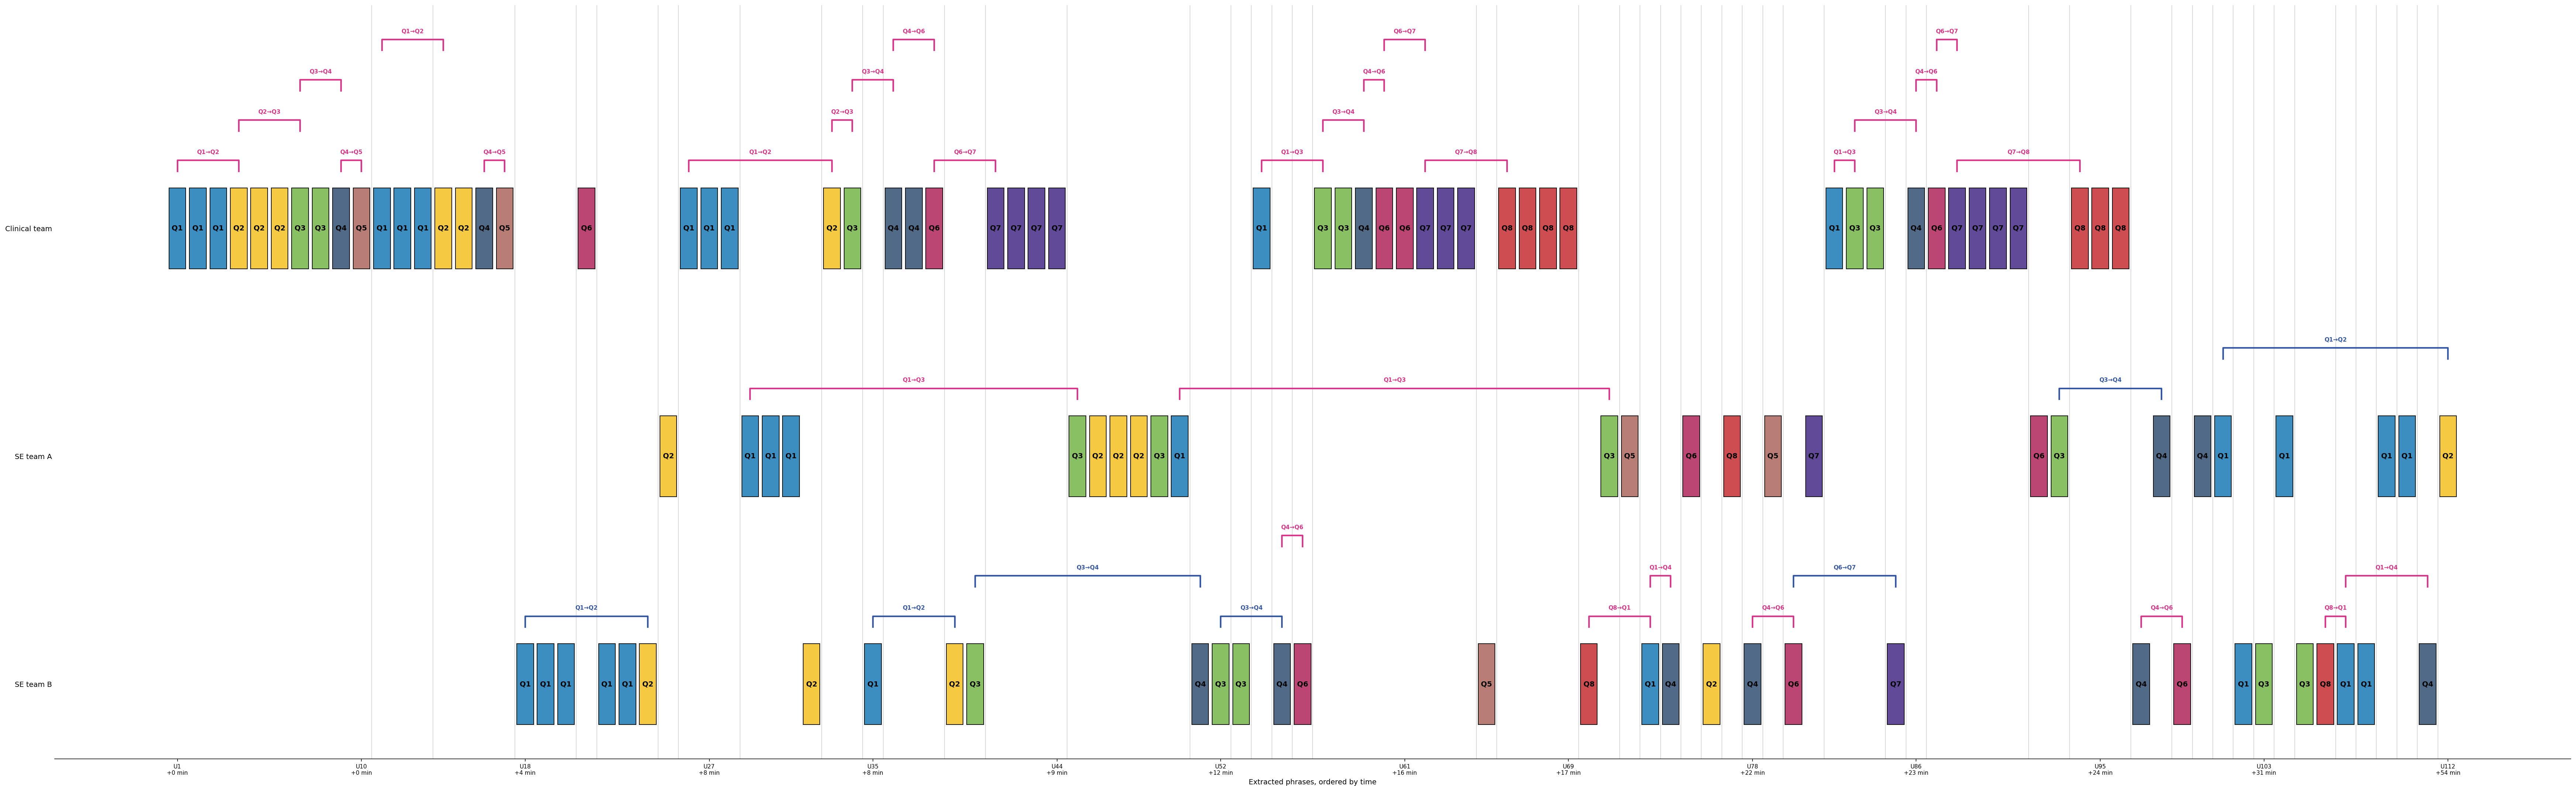

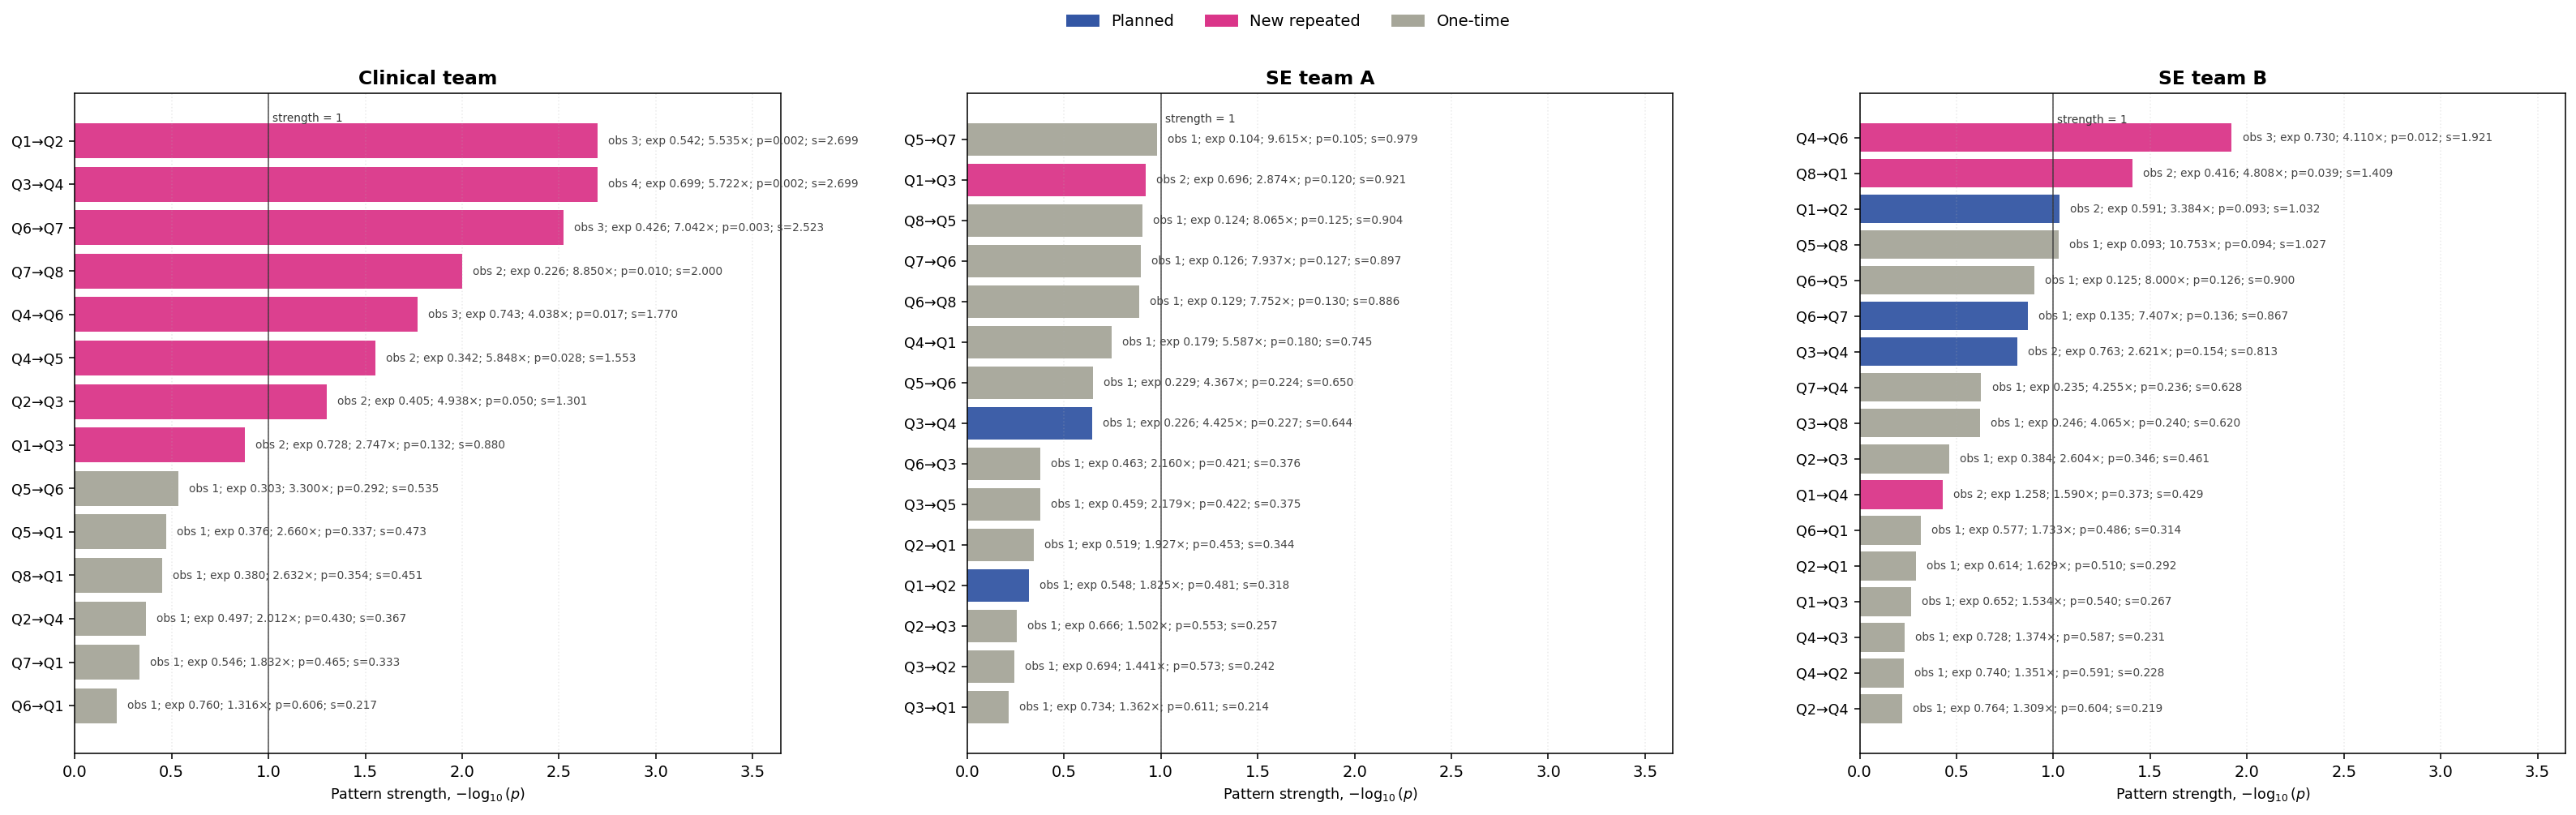

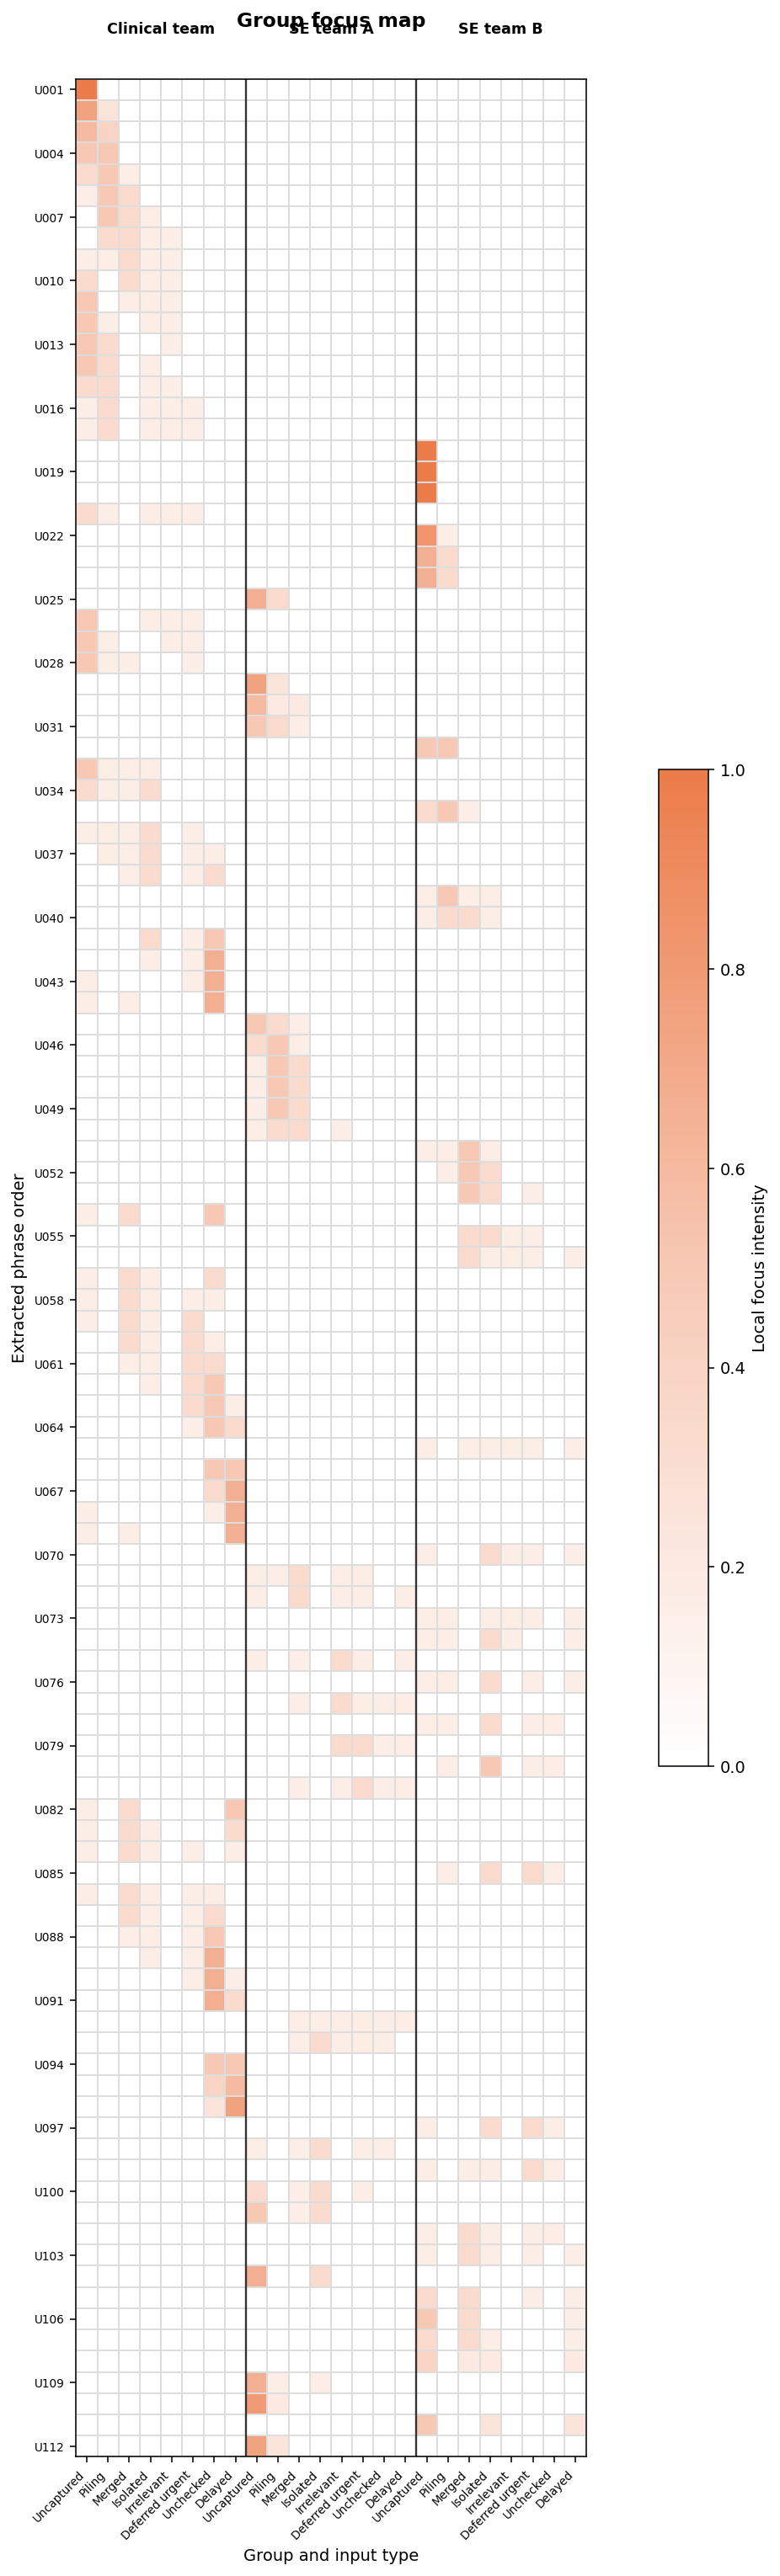

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


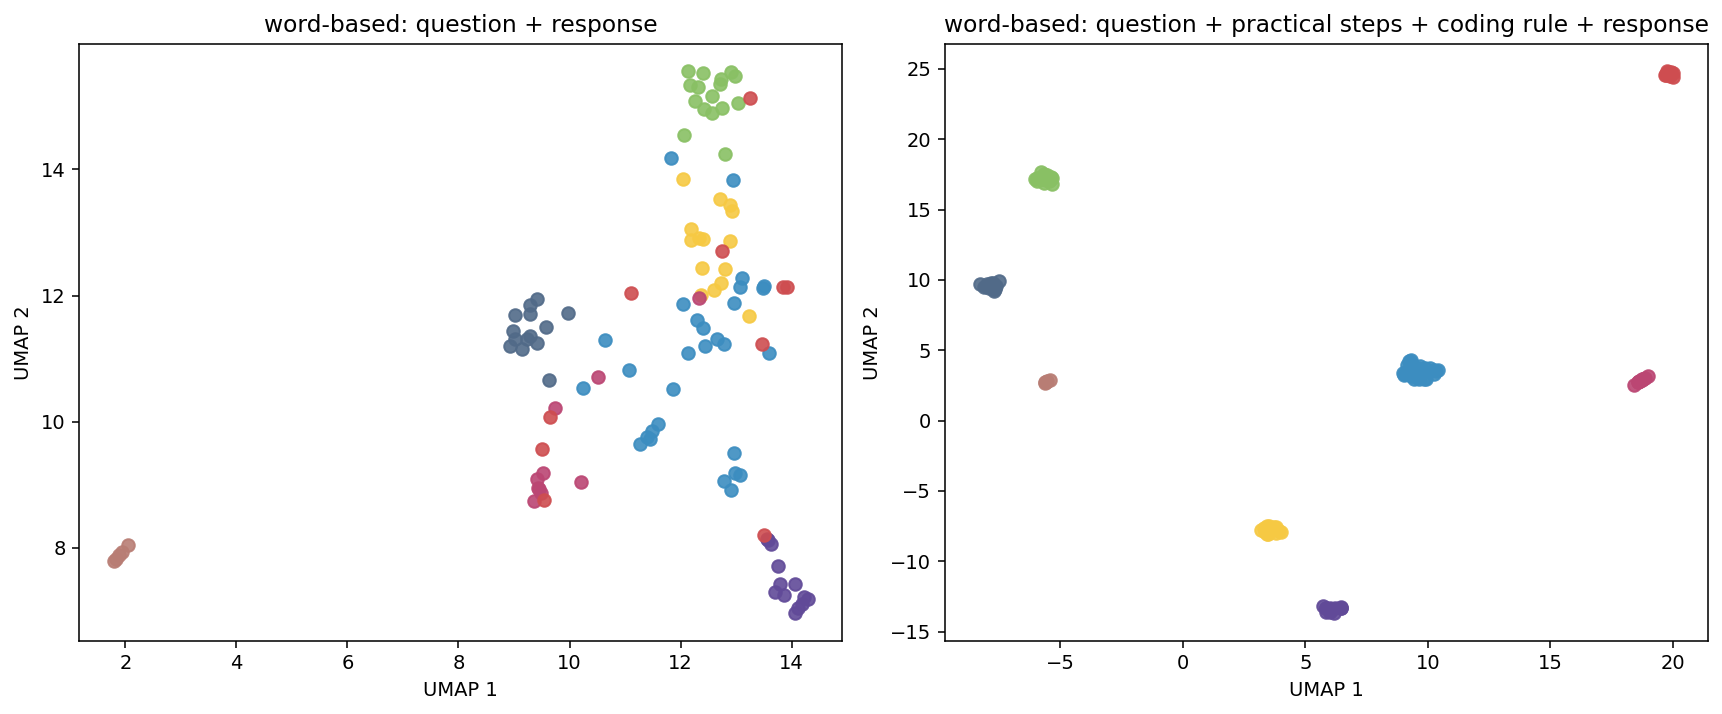

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


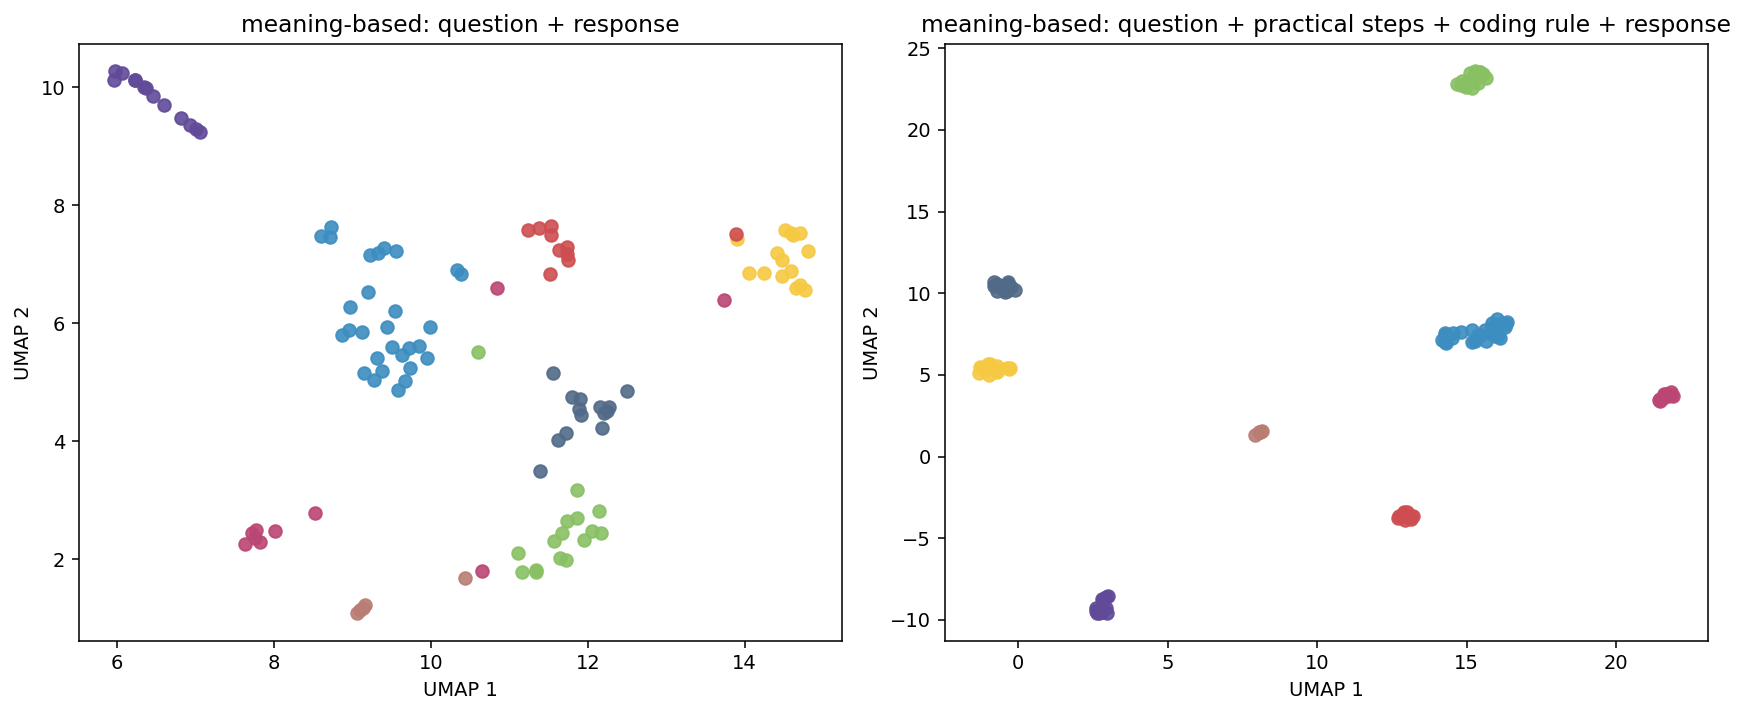

Visualization complete.
Figures saved in: /content/pilot_analysis_outputs/figures
Supplementary data ZIP: /content/pilot_analysis_outputs/data_and_analysis_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ============================================================
# STEP 2. VISUALIZATION AND EXPORT TABLES + IMAGES
# Starts from processed CSV files
# Saves SVG, PDF, EPS, PNG and one ZIP archive
# ============================================================

!pip -q install matplotlib umap-learn scikit-learn sentence-transformers

from pathlib import Path
import shutil
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap

from sklearn.feature_extraction.text import TfidfVectorizer
import umap
from sentence_transformers import SentenceTransformer

OUT_DIR = Path("/content/pilot_analysis_outputs")
DATA_DIR = OUT_DIR / "data"
INTERMEDIATE_DIR = OUT_DIR / "intermediate"
FIGURE_DIR = OUT_DIR / "figures"

for folder in [OUT_DIR, DATA_DIR, INTERMEDIATE_DIR, FIGURE_DIR]:
    folder.mkdir(exist_ok=True)

PLOT = {
    "sequence_max_x_ticks": 14,
    "sequence_item_size": 1.85,
    "sequence_actor_spacing": 5.2,
    "heatmap_cell_size": 0.18,
    "heatmap_color": "#EC7C49",
    "umap_n_neighbors": 10,
    "umap_min_dist": 0.10,
    "umap_random_state": 42
}

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["figure.dpi"] = 140
mpl.rcParams["savefig.dpi"] = 300

BREAKDOWN_COLORS = {
    "Uncaptured inputs": "#3C8DC0",
    "Piling inputs": "#F6C943",
    "Merged inputs": "#89C064",
    "Isolated inputs": "#516A88",
    "Irrelevant inputs": "#B87D74",
    "Deferred urgent inputs": "#BB4673",
    "Unchecked inputs": "#614A98",
    "Delayed inputs": "#CE4D50"
}

PATTERN_COLORS = {
    "planned": "#3356A4",
    "new repeated": "#DA3589",
    "one-time": "#A6A699"
}

ACTOR_ORDER = ["Clinical input", "Team A", "Team B"]

ACTOR_LABELS = {
    "Clinical input": "Clinical team",
    "Team A": "SE team A",
    "Team B": "SE team B"
}

def actor_label(actor):
    return ACTOR_LABELS.get(actor, actor)

def get_actor_order(values):
    values = list(pd.Series(values).dropna().drop_duplicates())
    out = [a for a in ACTOR_ORDER if a in values]
    out += [a for a in values if a not in out]
    return out

def save_figure(fig, filename_without_ext):
    path = Path(filename_without_ext)
    for ext in ["svg", "pdf", "eps", "png"]:
        fig.savefig(path.with_suffix(f".{ext}"), format=ext, facecolor="white", edgecolor="none")

reference_table = pd.read_csv(DATA_DIR / "01_reference_table.csv")
coding_units = pd.read_csv(DATA_DIR / "02_preprocessed_coding_units.csv")
collapsed_units = pd.read_csv(DATA_DIR / "03_collapsed_units_for_patterns.csv")
pattern_strength = pd.read_csv(DATA_DIR / "04_transition_results.csv")
group_focus = pd.read_csv(DATA_DIR / "05_group_focus.csv")
text_versions = pd.read_csv(DATA_DIR / "07_text_versions.csv")

# Rebuild plotting helpers directly from the substantive supplementary tables.
# This keeps the visualization step independent of temporary/intermediate files.
sequence_plot_data = coding_units.sort_values(
    ["original_row_order", "unit_number_in_entry"]
).reset_index(drop=True).copy()
sequence_plot_data["x_position"] = np.arange(len(sequence_plot_data)) * 2.25
sequence_plot_data["phrase_index"] = np.arange(1, len(sequence_plot_data) + 1)

parsed_time = pd.to_datetime(sequence_plot_data["timestamp"], errors="coerce")
if parsed_time.notna().sum() == 0:
    parsed_time = pd.to_datetime(
        "2000-01-01 " + sequence_plot_data["timestamp"].astype(str),
        errors="coerce"
    )
sequence_plot_data["parsed_timestamp"] = parsed_time
if parsed_time.notna().sum() > 0:
    first_time = parsed_time.dropna().min()
    sequence_plot_data["elapsed_minutes"] = (
        parsed_time - first_time
    ).dt.total_seconds() / 60
else:
    sequence_plot_data["elapsed_minutes"] = np.nan

separator_rows = []
for i in range(1, len(sequence_plot_data)):
    prev = sequence_plot_data.iloc[i - 1]
    cur = sequence_plot_data.iloc[i]
    if (
        prev["decision_point"] != cur["decision_point"]
        or prev["timestamp"] != cur["timestamp"]
    ):
        separator_rows.append({
            "line_x": (prev["x_position"] + cur["x_position"]) / 2,
            "phrase_index": cur["phrase_index"],
        })
sequence_separators = pd.DataFrame(separator_rows)

planned_pairs = {("Q1", "Q2"), ("Q3", "Q4"), ("Q6", "Q7")}
event_rows = []
for actor, g in collapsed_units.groupby("actor"):
    g = g.sort_values(["original_row_order", "unit_number_in_entry"]).reset_index(drop=True)
    paths = [(g.loc[i, "question_code"], g.loc[i + 1, "question_code"]) for i in range(len(g) - 1)]
    counts = pd.Series(paths).value_counts().to_dict()
    for i, path in enumerate(paths):
        count = counts[path]
        if actor in {"Team A", "Team B"} and path in planned_pairs:
            pattern_type = "planned"
        elif count >= 2:
            pattern_type = "new repeated"
        else:
            pattern_type = "one-time"
        event_rows.append({
            "actor": actor,
            "start_unit_id": g.loc[i, "coding_unit_id"],
            "end_unit_id": g.loc[i + 1, "coding_unit_id"],
            "question_path": f"{path[0]}→{path[1]}",
            "pattern_type": pattern_type,
        })
pattern_events = pd.DataFrame(event_rows)

focus_axis = sequence_plot_data[[
    "coding_unit_id", "global_order", "timestamp", "time_point", "decision_point",
    "actor", "actor_label", "question_code", "breakdown", "short_breakdown",
    "coding_unit_text", "original_entry"
]].copy()

breakdown_order = reference_table["breakdown"].tolist()
focus_columns = []
for actor in [a for a in ACTOR_ORDER if a in coding_units["actor"].unique()]:
    for breakdown in breakdown_order:
        short = reference_table.loc[
            reference_table["breakdown"] == breakdown, "short_breakdown"
        ].iloc[0]
        focus_columns.append({
            "actor": actor,
            "actor_label": actor_label(actor),
            "breakdown": breakdown,
            "short_breakdown": short,
        })
focus_column_info = pd.DataFrame(focus_columns)

QUESTION_ORDER = reference_table["question_code"].tolist()
QUESTION_COLORS = {
    row["question_code"]: BREAKDOWN_COLORS[row["breakdown"]]
    for _, row in reference_table.iterrows()
}

def assign_level(levels, x0, x1, pad=4.8):
    interval = (x0 - pad, x1 + pad)
    for level, used in enumerate(levels):
        if all(interval[1] < a or interval[0] > b for a, b in used):
            used.append(interval)
            return level
    levels.append([interval])
    return len(levels) - 1

def sequence_ticks(df):
    n = len(df)
    idxs = np.linspace(1, n, min(PLOT["sequence_max_x_ticks"], n)).round().astype(int)
    pos, lab = [], []
    for idx in idxs:
        row = df.loc[df["phrase_index"] == idx].iloc[0]
        pos.append(row["x_position"])
        lab.append(f"U{idx}\n+{row['elapsed_minutes']:.0f} min")
    return pos, lab

def plot_sequence_map():
    actor_order = get_actor_order(sequence_plot_data["actor"])
    actor_to_y = {a: (len(actor_order) - i - 1) * PLOT["sequence_actor_spacing"] for i, a in enumerate(actor_order)}

    fig, ax = plt.subplots(figsize=(max(36, sequence_plot_data["x_position"].max() / 5), 7 + 2.8 * len(actor_order)))

    for _, row in sequence_separators.iterrows():
        ax.axvline(row["line_x"], color="#D0D0D0", linewidth=0.8, zorder=0)

    positions = {}
    s = PLOT["sequence_item_size"]

    for _, row in sequence_plot_data.iterrows():
        x, y = row["x_position"], actor_to_y[row["actor"]]
        positions[(row["actor"], row["coding_unit_id"])] = (x, y)

        ax.add_patch(mpatches.Rectangle(
            (x - s / 2, y - s / 2), s, s,
            facecolor=BREAKDOWN_COLORS[row["breakdown"]],
            edgecolor="#111111", linewidth=1
        ))

        ax.text(x, y, row["question_code"], ha="center", va="center", fontsize=10, fontweight="bold")

    for _, row in pattern_events[pattern_events["pattern_type"].isin(["planned", "new repeated"])].iterrows():
        k1 = (row["actor"], row["start_unit_id"])
        k2 = (row["actor"], row["end_unit_id"])
        if k1 not in positions or k2 not in positions:
            continue

        x0, y = positions[k1]
        x1, _ = positions[k2]
        if x1 < x0:
            x0, x1 = x1, x0

        levels = getattr(plot_sequence_map, "levels", {})
        if row["actor"] not in levels:
            levels[row["actor"]] = []
        plot_sequence_map.levels = levels

        level = assign_level(levels[row["actor"]], x0, x1)
        y_top = y + 1.55 + level * 0.92

        ax.plot([x0, x0, x1, x1], [y_top - .25, y_top, y_top, y_top - .25],
                color=PATTERN_COLORS[row["pattern_type"]], linewidth=2.2)

        ax.text((x0 + x1) / 2, y_top + .12, row["question_path"],
                ha="center", va="bottom", fontsize=8,
                color=PATTERN_COLORS[row["pattern_type"]], fontweight="bold")

    ax.set_yticks([actor_to_y[a] for a in actor_order])
    ax.set_yticklabels([actor_label(a) for a in actor_order])
    ax.set_xticks(sequence_ticks(sequence_plot_data)[0])
    ax.set_xticklabels(sequence_ticks(sequence_plot_data)[1], fontsize=8)
    ax.set_xlabel("Extracted phrases, ordered by time")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

    plt.tight_layout()
    save_figure(fig, FIGURE_DIR / "input_breakdown_sequence_map")
    plt.show()

def plot_pattern_strength():
    """
    Plot pattern strength for all observed transitions.
    Labels are aligned with Table repeated_patterns:
    observed transition count, expected transition count,
    observed/expected ratio, p value, and pattern strength.
    """

    plot_df = pattern_strength.copy()

    # keep all rows, but sort within each team by strength
    actor_order = get_actor_order(plot_df["actor"])

    xmax = max(plot_df["strength_after_random_order"].max() * 1.35, 1.2)

    fig, axes = plt.subplots(
        1,
        len(actor_order),
        figsize=(7.6 * len(actor_order), 7.2),
        sharex=True
    )

    if len(actor_order) == 1:
        axes = [axes]

    for ax, actor in zip(axes, actor_order):

        df = (
            plot_df[plot_df["actor"] == actor]
            .sort_values("strength_after_random_order", ascending=True)
            .reset_index(drop=True)
        )

        y = np.arange(len(df))

        ax.barh(
            y,
            df["strength_after_random_order"],
            color=df["pattern_type"].map(PATTERN_COLORS),
            alpha=0.95
        )

        ax.axvline(
            1.0,
            color="#333333",
            linewidth=0.9,
            alpha=0.75
        )

        ax.text(
            1.02,
            len(df) - 0.35,
            "strength = 1",
            fontsize=7,
            va="top",
            ha="left",
            color="#333333"
        )

        ax.set_yticks(y)
        ax.set_yticklabels(df["question_path"], fontsize=9)

        ax.set_xlim(0, xmax)
        ax.set_title(actor_label(actor), fontsize=12, fontweight="bold")
        ax.set_xlabel("Pattern strength, $-\\log_{10}(p)$", fontsize=9)
        ax.grid(axis="x", linestyle=":", alpha=0.25)

        for i, row in df.iterrows():

            label = (
                f"obs {int(row['times_seen'])}; "
                f"exp {row['expected_after_random_order']:.3f}; "
                f"{row['times_more_than_expected']:.3f}×; "
                f"p={row['random_order_p_value']:.3f}; "
                f"s={row['strength_after_random_order']:.3f}"
            )

            ax.text(
                row["strength_after_random_order"] + xmax * 0.015,
                i,
                label,
                va="center",
                ha="left",
                fontsize=7,
                color="#444444"
            )

    handles = [
        mpatches.Patch(color=PATTERN_COLORS["planned"], label="Planned"),
        mpatches.Patch(color=PATTERN_COLORS["new repeated"], label="New repeated"),
        mpatches.Patch(color=PATTERN_COLORS["one-time"], label="One-time")
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=10
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    save_figure(fig, FIGURE_DIR / "repeated_breakdown_patterns")
    plt.show()

def plot_group_focus():
    n_rows, n_cols = len(focus_axis), len(focus_column_info)
    matrix = np.zeros((n_rows, n_cols))

    lookup = {(r["actor"], r["breakdown"]): i for i, r in focus_column_info.iterrows()}

    for _, row in group_focus.iterrows():
        matrix[int(row["global_order"]) - 1, lookup[(row["actor"], row["focus_breakdown"])]] = row["local_focus_intensity"]

    cmap = LinearSegmentedColormap.from_list("focus", ["#FFFFFF", "#F7C9B5", PLOT["heatmap_color"]])

    cell = PLOT["heatmap_cell_size"]
    fig, ax = plt.subplots(figsize=(max(8.5, n_cols * cell + 3.8), max(12, n_rows * cell + 1.8)))

    mesh = ax.pcolormesh(np.arange(n_cols + 1), np.arange(n_rows + 1), matrix,
                         cmap=cmap, vmin=0, vmax=1,
                         edgecolors="#DDDDDD", linewidth=.25)

    ax.invert_yaxis()
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n_cols) + .5)
    ax.set_xticklabels(focus_column_info["short_breakdown"], rotation=45, ha="right", fontsize=7)

    step = max(1, int(np.ceil(n_rows / 45)))
    yticks = list(range(0, n_rows, step))
    ax.set_yticks(np.array(yticks) + .5)
    ax.set_yticklabels([focus_axis.loc[i, "coding_unit_id"] for i in yticks], fontsize=7)

    for actor in focus_column_info["actor"].drop_duplicates():
        cols = focus_column_info.index[focus_column_info["actor"] == actor].tolist()
        if cols[0] > 0:
            ax.axvline(cols[0], color="#333333", linewidth=1.2)
        ax.text((cols[0] + cols[-1] + 1) / 2, -2, actor_label(actor),
                ha="center", va="bottom", fontsize=9, fontweight="bold", clip_on=False)

    ax.set_title("Group focus map", fontweight="bold", pad=32)
    ax.set_xlabel("Group and input type")
    ax.set_ylabel("Extracted phrase order")

    cbar = fig.colorbar(mesh, ax=ax, fraction=.055, pad=.08, shrink=.82)
    cbar.set_label("Local focus intensity")

    plt.tight_layout()
    save_figure(fig, FIGURE_DIR / "group_focus_map")
    plt.show()

def plot_umap_maps(method, filename):
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

    specs = [
        ("question_response", "question + response"),
        ("question_steps_rule_response", "question + practical steps + coding rule + response")
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))

    for ax, (col, title) in zip(axes, specs):
        if method == "tfidf":
            X = TfidfVectorizer(stop_words="english", ngram_range=(1, 2)).fit_transform(text_versions[col].fillna(""))
            label = "word-based"
        else:
            X = model.encode(text_versions[col].fillna("").tolist(), convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)
            label = "meaning-based"

        coords = umap.UMAP(
            n_neighbors=PLOT["umap_n_neighbors"],
            min_dist=PLOT["umap_min_dist"],
            metric="cosine",
            random_state=PLOT["umap_random_state"]
        ).fit_transform(X)

        for q in QUESTION_ORDER:
            mask = text_versions["question_code"] == q
            ax.scatter(coords[mask, 0], coords[mask, 1], s=42, color=QUESTION_COLORS[q], alpha=.9)

        ax.set_title(f"{label}: {title}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    save_figure(fig, FIGURE_DIR / filename)
    plt.show()

plot_sequence_map()
plot_pattern_strength()
plot_group_focus()
plot_umap_maps("tfidf", "word_based_breakdown_map")
plot_umap_maps("embedding", "meaning_based_breakdown_map")

# ------------------------------------------------------------
# FINAL REQUIREMENT STATEMENTS
# The wording below is transcribed from the Team A and Team B
# study-board screenshots and is intentionally preserved.
# ------------------------------------------------------------

team_a_requirements = 'FR01 - The system shall capture each clinical observation with its source, timestamp, and updated status so that the team can trace where the information came from and how current it is\nFR02 - The system shall indicate missing critical data needed for the current assessment so that the team can identify what info/data is still needed.\nFR03 - The system shall allow clinicians to compare current findings with previous results so that changes, deterioration, or consistency can be identified quickly.\n\nQR01 - The system shall provide fast lab result in 3 seconds to support data findings for clinical treatment.\n'
team_b_requirements = "R1 - The system shall allow professionals to flag patients to indicate the severity of their case;\nIncludes high importance, low importance\nR2 - The system shall allow the Emergency Physician that takes the case to send it to a specific specialist.\nR3 - The system shall display imaging results, monitoring devices and laboratory results in their own sections to professionals in the case.\nR4 - The system shall have a real-time dashboard for professionals to have a unified system for information\nR5 - The system shall allow hospital staff to contact laboratories for testing within 5 minutes of admission\nR6 - The system shall provide professionals a unified medical history and the ability to see the specific patient's history.\nR7 - The system shall have a real-time log for observations in results or in the case file.\nR8 - The system shall give visual warnings to professionals if a patient is in critical condition\nR9 - The system shall allow professionals to tags different results and data together.\nR10 - The system shall have an audit log of all decisions taken for accountability and transparency.\n"

(DATA_DIR / "11_team_A_final_requirements.txt").write_text(
    team_a_requirements, encoding="utf-8"
)
(DATA_DIR / "12_team_B_final_requirements.txt").write_text(
    team_b_requirements, encoding="utf-8"
)

readme_text = """# Supplementary File S3 — data and analysis outputs

This package contains the original board-log input, processed coding units, derived analysis tables, and the final requirement statements used in the manuscript.

## Data provenance

`00_board_logs.csv` is the original board-log table supplied to the computational notebook. It is the source input for the processing and analyses in this package.

The remaining CSV files are processed or derived from this input. The computational notebook supplied with Supplementary File S3 documents the processing steps and regenerates the reported analyses and figures.

## Files

- `00_board_logs.csv` — original board-log table used as input.
- `01_reference_table.csv` — mapping of Q1–Q8 to the guiding questions, breakdown labels, practical steps, and coding rules.
- `02_preprocessed_coding_units.csv` — coding units obtained by splitting the board-log entries and attaching the corresponding question metadata.
- `03_collapsed_units_for_patterns.csv` — coding-unit sequences after consecutive repetitions of the same question code were collapsed for transition analysis.
- `04_transition_results.csv` — observed and expected transition counts, observed-to-expected ratios, permutation p values, and pattern strength.
- `05_group_focus.csv` — local group-focus values calculated from neighbouring coding units.
- `06_high_focus_units.csv` — coding units associated with selected high-focus regions used in the interpretation of the group-focus analysis.
- `07_text_versions.csv` — text representations used in the question-fit analysis.
- `08_text_separation_summary.csv` — summary of the TF-IDF and sentence-embedding separation analyses.
- `09_q8_wording_alignment.csv` — lexical-semantic comparison of the original and alternative wording of Q8.
- `10_general_summary.csv` — analysis settings and summary checks.
- `11_team_A_final_requirements.txt` — final requirement statements recorded for Team A.
- `12_team_B_final_requirements.txt` — final requirement statements recorded for Team B.

## Computational notebook

The computational notebook is supplied with Supplementary File S3. Run it from top to bottom and upload the original board-log CSV when prompted. The notebook preserves that input as `00_board_logs.csv`, generates the processed and derived tables listed above, regenerates the manuscript figures, writes the two requirement text files, and creates the supplementary ZIP archive.

## Files intentionally excluded

Intermediate plotting helpers and duplicate figure exports in EPS, PDF, PNG, and SVG formats are not included in the supplementary ZIP because they can be regenerated from the supplied data and notebook.

## Related supplementary files

- Supplementary File S1 contains the original Miro board records in `.rtb` format.
- Supplementary File S2 contains the printed card materials.
"""
(DATA_DIR / "README.md").write_text(readme_text, encoding="utf-8")

zip_base = OUT_DIR / "data_and_analysis_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", DATA_DIR)

print("Visualization complete.")
print("Figures saved in:", FIGURE_DIR)
print("Supplementary data ZIP:", zip_path)

from google.colab import files
files.download(zip_path)